# 🎙️ Speech Emotion Recognition

## Task 2 — Model Training

In this notebook, a CNN-based deep learning model is trained
using MFCC features extracted from the RAVDESS dataset.

### Objectives

- Load extracted MFCC features
- Encode emotion labels
- Split dataset into training, validation and testing sets
- Calculate class weights
- Build CNN model
- Train the model
- Monitor training and validation performance
- Generate training graphs
- Save the best model
- Evaluate basic test performance

### Dataset

RAVDESS Speech Emotion Dataset

### Features

MFCC

### Model

Convolutional Neural Network (CNN)

## 1. Import Required Libraries

In [1]:
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    TensorDataset,
    DataLoader
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

print("✓ Libraries imported successfully")
print("PyTorch version:", torch.__version__)

✓ Libraries imported successfully
PyTorch version: 2.13.0+cpu


## 2. Device Configuration

The model automatically uses:

- CUDA GPU if available
- Otherwise CPU

In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Selected device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Training will use CPU.")

Selected device: cpu
Training will use CPU.


## 3. Load Extracted MFCC Features

The features generated in:

`02_Feature_Extraction.ipynb`

are loaded from the `outputs` directory.

In [3]:
FEATURE_FILE = "../outputs/mfcc_features.npy"
LABEL_FILE = "../outputs/mfcc_labels.npy"

if not os.path.exists(FEATURE_FILE):
    raise FileNotFoundError(
        f"Feature file not found:\n{FEATURE_FILE}"
    )

if not os.path.exists(LABEL_FILE):
    raise FileNotFoundError(
        f"Label file not found:\n{LABEL_FILE}"
    )

X = np.load(FEATURE_FILE)
y = np.load(
    LABEL_FILE,
    allow_pickle=True
)

print("Features loaded successfully!")
print()
print("Feature shape:", X.shape)
print("Label shape:", y.shape)

Features loaded successfully!

Feature shape: (1440, 40, 94)
Label shape: (1440,)


In [5]:
print("Dataset Information")
print("====================")

print("Total samples:", len(X))
print("MFCC coefficients:", X.shape[1])
print("Time steps:", X.shape[2])

print("\nEmotion classes:")

for emotion in sorted(np.unique(y)):
    print(
        f"{emotion:10s} : {np.sum(y == emotion)}"
    )

Dataset Information
Total samples: 1440
MFCC coefficients: 40
Time steps: 94

Emotion classes:
angry      : 192
calm       : 192
disgust    : 192
fearful    : 192
happy      : 192
neutral    : 96
sad        : 192
surprised  : 192


## 4. Emotion Distribution

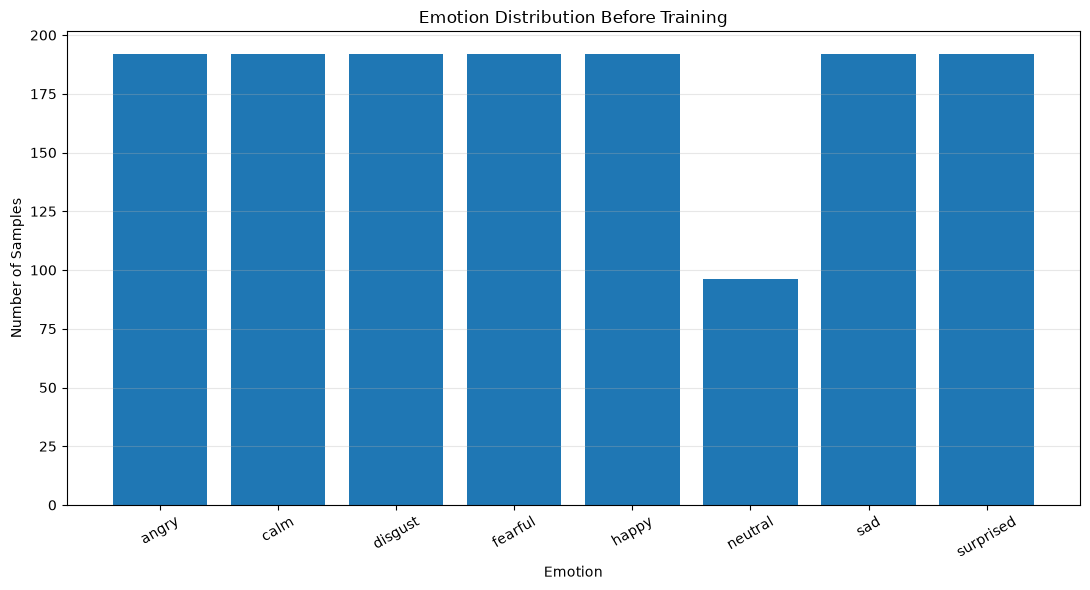

In [6]:
emotion_counts = (
    pd.Series(y)
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(11, 6))

plt.bar(
    emotion_counts.index,
    emotion_counts.values
)

plt.title(
    "Emotion Distribution Before Training"
)

plt.xlabel("Emotion")
plt.ylabel("Number of Samples")

plt.xticks(rotation=30)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 5. Encode Emotion Labels

The emotion names are converted into numerical classes
for neural network training.

In [7]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

class_names = list(
    label_encoder.classes_
)

num_classes = len(class_names)

print("Number of classes:", num_classes)

print("\nClass Mapping:")

for index, emotion in enumerate(class_names):
    print(
        f"{index} → {emotion}"
    )

Number of classes: 8

Class Mapping:
0 → angry
1 → calm
2 → disgust
3 → fearful
4 → happy
5 → neutral
6 → sad
7 → surprised


In [8]:
os.makedirs(
    "../models",
    exist_ok=True
)

label_mapping = {
    str(index): emotion
    for index, emotion
    in enumerate(class_names)
}

with open(
    "../models/emotion_labels.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        label_mapping,
        file,
        indent=4
    )

print(
    "✓ Label mapping saved to:"
)

print(
    "../models/emotion_labels.json"
)

✓ Label mapping saved to:
../models/emotion_labels.json


## 6. Feature Normalization

MFCC values are normalized using the mean and standard deviation
of the complete feature dataset.

In [9]:
X = X.astype(
    np.float32
)

mean = X.mean()

std = X.std()

X_normalized = (
    X - mean
) / (
    std + 1e-8
)

print("Normalization completed.")

print(
    "Mean after normalization:",
    X_normalized.mean()
)

print(
    "Std after normalization:",
    X_normalized.std()
)

Normalization completed.
Mean after normalization: -3.6072787e-09
Std after normalization: 1.0


## 7. Dataset Splitting

Dataset split:

- 70% Training
- 15% Validation
- 15% Testing

Stratified splitting is used so that each emotion
is represented proportionally.

In [10]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_normalized,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Dataset Split")
print("=============")

print(
    f"Training   : {len(X_train)}"
)

print(
    f"Validation : {len(X_val)}"
)

print(
    f"Testing    : {len(X_test)}"
)

Dataset Split
Training   : 1008
Validation : 216
Testing    : 216


## 8. Prepare CNN Input

PyTorch Conv2D expects:

`Batch × Channels × Height × Width`

Therefore:

`(1440, 40, 94)`

becomes:

`(1440, 1, 40, 94)`

In [11]:
X_train = np.expand_dims(
    X_train,
    axis=1
)

X_val = np.expand_dims(
    X_val,
    axis=1
)

X_test = np.expand_dims(
    X_test,
    axis=1
)

print("CNN Input Shapes")

print(
    "Training   :",
    X_train.shape
)

print(
    "Validation :",
    X_val.shape
)

print(
    "Testing    :",
    X_test.shape
)

CNN Input Shapes
Training   : (1008, 1, 40, 94)
Validation : (216, 1, 40, 94)
Testing    : (216, 1, 40, 94)


In [12]:
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.long
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

print("✓ Tensor conversion completed")

✓ Tensor conversion completed


In [13]:
BATCH_SIZE = 32

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoaders created successfully.")

print(
    "Training batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

print(
    "Testing batches:",
    len(test_loader)
)

DataLoaders created successfully.
Training batches: 32
Validation batches: 7
Testing batches: 7


## 9. Calculate Class Weights

Class weights help the model handle imbalance between
emotion classes.

In [14]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("Class Weights")
print("=============")

for index, weight in enumerate(
    class_weights
):

    print(
        f"{class_names[index]:10s} → {weight:.4f}"
    )

Class Weights
angry      → 0.9333
calm       → 0.9333
disgust    → 0.9403
fearful    → 0.9403
happy      → 0.9403
neutral    → 1.8806
sad        → 0.9333
surprised  → 0.9403


## 10. CNN Model Architecture

The model contains:

- Convolutional layers
- Batch Normalization
- ReLU activation
- Max Pooling
- Dropout
- Adaptive Average Pooling
- Fully Connected layers

Adaptive pooling allows the classifier to receive
a fixed-size representation.

In [15]:
class EmotionCNN(nn.Module):

    def __init__(
        self,
        num_classes
    ):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Dropout(0.15),


            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Dropout(0.20),


            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Dropout(0.25),


            nn.Conv2d(
                128,
                256,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(256),

            nn.ReLU(),

            nn.Dropout(0.30)
        )

        self.pool = nn.AdaptiveAvgPool2d(
            (4, 4)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                256 * 4 * 4,
                128
            ),

            nn.ReLU(),

            nn.BatchNorm1d(128),

            nn.Dropout(0.40),

            nn.Linear(
                128,
                num_classes
            )
        )


    def forward(self, x):

        x = self.features(x)

        x = self.pool(x)

        x = self.classifier(x)

        return x

In [16]:
model = EmotionCNN(
    num_classes=num_classes
).to(device)

print(model)

EmotionCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.15, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.2, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout(p=0.25, inplace=False)
    (15): Co

## 11. Loss Function and Optimizer

In [17]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

optimizer = optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

print("✓ Loss function:", criterion)
print("✓ Optimizer: AdamW")
print("✓ Learning rate: 0.001")

✓ Loss function: CrossEntropyLoss()
✓ Optimizer: AdamW
✓ Learning rate: 0.001


In [18]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    total_loss = 0.0
    predictions = []
    targets = []

    for batch_x, batch_y in loader:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_x)

        loss = criterion(
            outputs,
            batch_y
        )

        loss.backward()

        optimizer.step()

        total_loss += (
            loss.item()
            * batch_x.size(0)
        )

        preds = torch.argmax(
            outputs,
            dim=1
        )

        predictions.extend(
            preds.detach().cpu().numpy()
        )

        targets.extend(
            batch_y.detach().cpu().numpy()
        )

    epoch_loss = (
        total_loss /
        len(loader.dataset)
    )

    epoch_accuracy = accuracy_score(
        targets,
        predictions
    )

    return epoch_loss, epoch_accuracy

In [19]:
def evaluate_model(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0.0

    predictions = []
    targets = []

    with torch.no_grad():

        for batch_x, batch_y in loader:

            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            outputs = model(batch_x)

            loss = criterion(
                outputs,
                batch_y
            )

            total_loss += (
                loss.item()
                * batch_x.size(0)
            )

            preds = torch.argmax(
                outputs,
                dim=1
            )

            predictions.extend(
                preds.cpu().numpy()
            )

            targets.extend(
                batch_y.cpu().numpy()
            )

    epoch_loss = (
        total_loss /
        len(loader.dataset)
    )

    epoch_accuracy = accuracy_score(
        targets,
        predictions
    )

    return (
        epoch_loss,
        epoch_accuracy,
        predictions,
        targets
    )

# 🚀 12. Model Training

The model will be trained for multiple epochs.

The best model is automatically saved based on
validation loss.

Training history is also stored for visualization.

In [20]:
EPOCHS = 40

best_val_loss = float("inf")

history = {
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": []
}

best_model_path = "../models/emotion_model.pth"

print("=" * 70)
print("STARTING CNN TRAINING")
print("=" * 70)

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc, _, _ = evaluate_model(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_loss)

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["train_accuracy"].append(
        train_acc
    )

    history["val_accuracy"].append(
        val_acc
    )

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc * 100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc * 100:.2f}% | "
        f"LR: {current_lr:.6f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            best_model_path
        )

        print(
            "   ✓ Best model saved!"
        )

print("\n✓ Training completed!")

STARTING CNN TRAINING
Epoch 01/40 | Train Loss: 1.9765 | Train Acc: 20.24% | Val Loss: 1.9772 | Val Acc: 18.52% | LR: 0.001000
   ✓ Best model saved!
Epoch 02/40 | Train Loss: 1.8422 | Train Acc: 27.48% | Val Loss: 2.3526 | Val Acc: 14.81% | LR: 0.001000
Epoch 03/40 | Train Loss: 1.8043 | Train Acc: 28.67% | Val Loss: 2.5762 | Val Acc: 15.74% | LR: 0.001000
Epoch 04/40 | Train Loss: 1.6783 | Train Acc: 36.01% | Val Loss: 2.6061 | Val Acc: 17.59% | LR: 0.001000
Epoch 05/40 | Train Loss: 1.6255 | Train Acc: 38.99% | Val Loss: 1.8203 | Val Acc: 31.48% | LR: 0.001000
   ✓ Best model saved!
Epoch 06/40 | Train Loss: 1.5611 | Train Acc: 42.46% | Val Loss: 2.5229 | Val Acc: 22.22% | LR: 0.001000
Epoch 07/40 | Train Loss: 1.4986 | Train Acc: 43.95% | Val Loss: 2.5226 | Val Acc: 23.61% | LR: 0.001000
Epoch 08/40 | Train Loss: 1.4386 | Train Acc: 48.02% | Val Loss: 2.1445 | Val Acc: 27.31% | LR: 0.001000
Epoch 09/40 | Train Loss: 1.3995 | Train Acc: 48.71% | Val Loss: 2.3480 | Val Acc: 23.61% | 

KeyboardInterrupt: 

In [21]:
history_df = pd.DataFrame(
    history
)

history_df.index += 1

history_df.index.name = "Epoch"

history_df.head()

,train_loss,val_loss,train_accuracy,val_accuracy
Epoch,,,,
1,1.976542,1.977200,0.202381,0.185185
2,1.842157,2.352626,0.274802,0.148148
3,1.804311,2.576192,0.286706,0.157407
4,1.678261,2.606112,0.360119,0.175926
5,1.625543,1.820281,0.389881,0.314815


## 13. Training vs Validation Loss

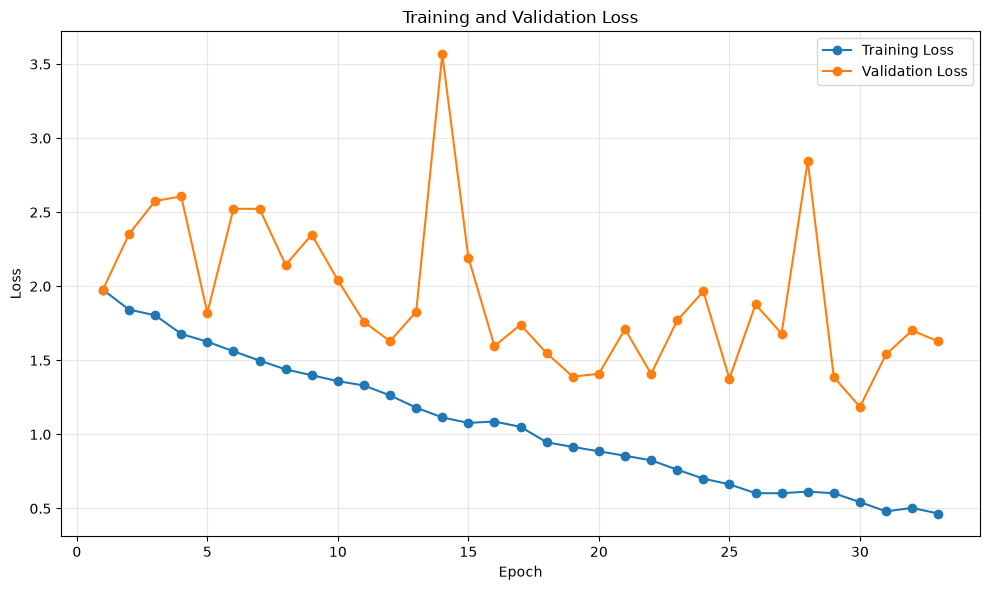

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_df.index,
    history_df["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_df.index,
    history_df["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title(
    "Training and Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## 14. Training vs Validation Accuracy

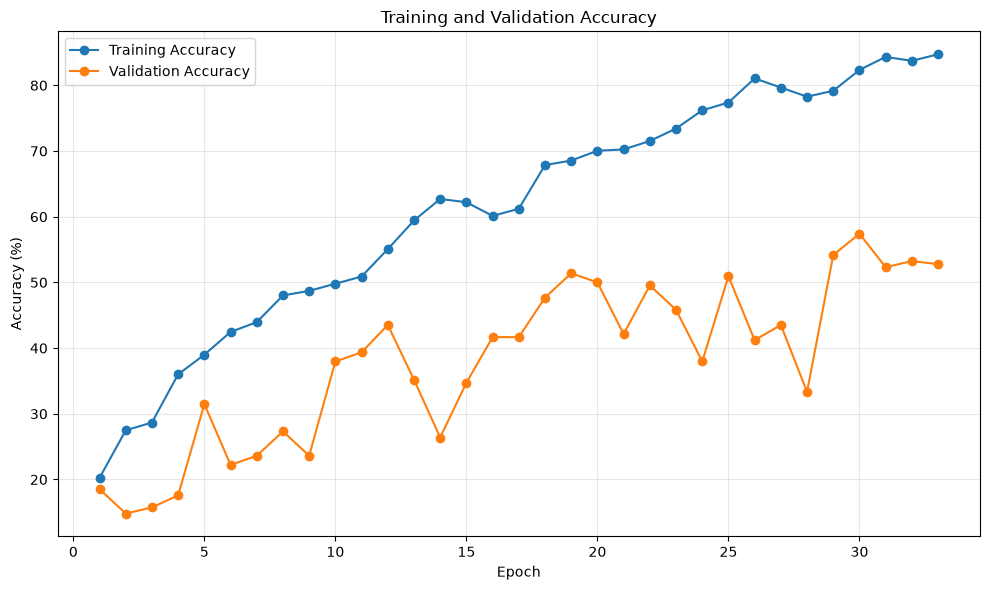

In [23]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_df.index,
    history_df["train_accuracy"] * 100,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history_df.index,
    history_df["val_accuracy"] * 100,
    marker="o",
    label="Validation Accuracy"
)

plt.title(
    "Training and Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [24]:
best_epoch = (
    history_df["val_loss"]
    .idxmin()
)

best_val_loss_value = (
    history_df.loc[
        best_epoch,
        "val_loss"
    ]
)

best_val_accuracy = (
    history_df.loc[
        best_epoch,
        "val_accuracy"
    ]
)

print("Best Training Epoch")
print("===================")

print(
    "Epoch:",
    best_epoch
)

print(
    f"Validation Loss: "
    f"{best_val_loss_value:.4f}"
)

print(
    f"Validation Accuracy: "
    f"{best_val_accuracy * 100:.2f}%"
)

Best Training Epoch
Epoch: 30
Validation Loss: 1.1857
Validation Accuracy: 57.41%


## 15. Load Best Saved Model

In [25]:
best_model = EmotionCNN(
    num_classes=num_classes
).to(device)

best_model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

best_model.eval()

print("✓ Best model loaded successfully")

print(
    "Model:",
    best_model_path
)

✓ Best model loaded successfully
Model: ../models/emotion_model.pth


## 16. Evaluate Model on Test Dataset

In [26]:
test_loss, test_accuracy, test_predictions, test_targets = (
    evaluate_model(
        best_model,
        test_loader,
        criterion,
        device
    )
)

print("=" * 50)
print("TEST RESULTS")
print("=" * 50)

print(
    f"Test Loss     : {test_loss:.4f}"
)

print(
    f"Test Accuracy : {test_accuracy * 100:.2f}%"
)

TEST RESULTS
Test Loss     : 1.1379
Test Accuracy : 58.80%


## 17. Classification Report

In [27]:
print(
    classification_report(
        test_targets,
        test_predictions,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

       angry     0.7000    0.7500    0.7241        28
        calm     0.7200    0.6207    0.6667        29
     disgust     0.5227    0.7931    0.6301        29
     fearful     0.4884    0.7241    0.5833        29
       happy     0.5714    0.4138    0.4800        29
     neutral     0.4500    0.6429    0.5294        14
         sad     0.5625    0.3103    0.4000        29
   surprised     0.8235    0.4828    0.6087        29

    accuracy                         0.5880       216
   macro avg     0.6048    0.5922    0.5778       216
weighted avg     0.6151    0.5880    0.5805       216



## 18. Confusion Matrix

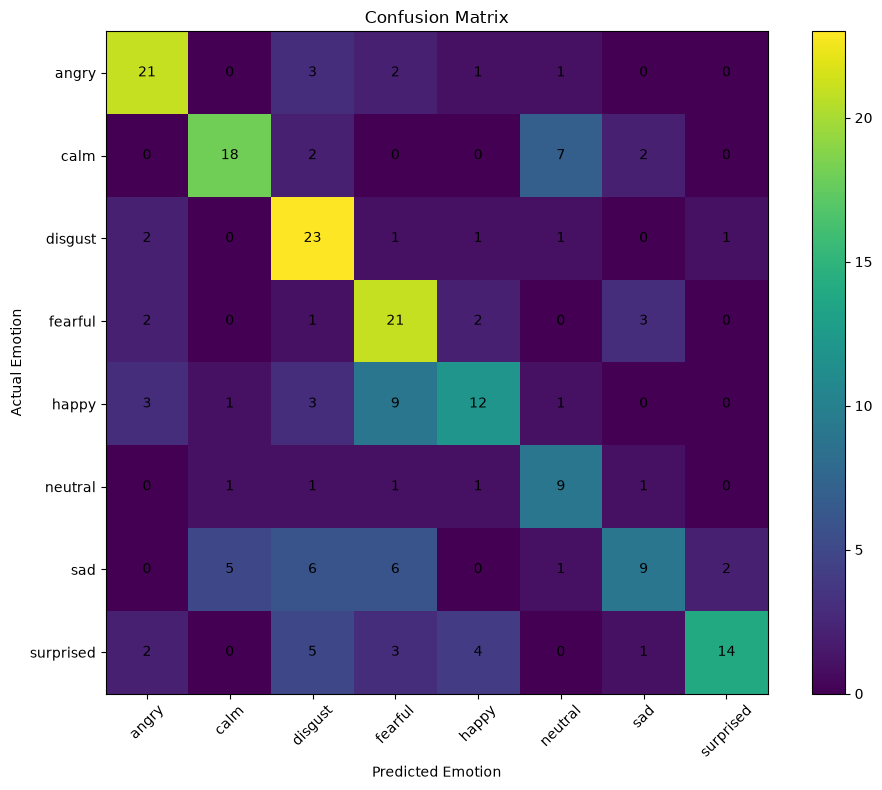

In [28]:
cm = confusion_matrix(
    test_targets,
    test_predictions
)

plt.figure(figsize=(10, 8))

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    "Confusion Matrix"
)

plt.colorbar()

plt.xticks(
    range(num_classes),
    class_names,
    rotation=45
)

plt.yticks(
    range(num_classes),
    class_names
)

plt.xlabel(
    "Predicted Emotion"
)

plt.ylabel(
    "Actual Emotion"
)

for i in range(num_classes):

    for j in range(num_classes):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.show()

## 19. Save Training Results

In [29]:
os.makedirs(
    "../outputs",
    exist_ok=True
)

history_df.to_csv(
    "../outputs/training_history.csv"
)

np.save(
    "../outputs/test_predictions.npy",
    np.array(test_predictions)
)

np.save(
    "../outputs/test_targets.npy",
    np.array(test_targets)
)

print("✓ Training history saved")
print("✓ Test predictions saved")
print("✓ Test targets saved")

✓ Training history saved
✓ Test predictions saved
✓ Test targets saved


# Conclusion

The CNN-based Speech Emotion Recognition model was successfully
trained using MFCC features extracted from the RAVDESS dataset.

The dataset was divided into training, validation, and testing
sets, and the model was trained using the AdamW optimizer and
Cross-Entropy Loss.

Training and validation performance was monitored using loss and
accuracy graphs. The best-performing model was saved for further
evaluation and prediction.

